# Analiza strategije guma u Formuli 1

Ovaj notebook prikazuje kompletan tok projekta: od prikupljanja i obrade podataka, preko primene modela, do evaluacije i interpretacije rezultata.

Cilj analize je da se razume izbor smese guma i da se uporede performanse modela klasifikacije i klasterovanja na realnim F1 podacima.


## 1. Učitavanje biblioteka i putanja

U ovom delu pripremamo okruženje i putanje do ulaznih podataka i izlaznih rezultata.
Time obezbeđujemo da se svaki sledeći korak izvršava nad istim lokacijama fajlova i da je ceo tok reproduktivan.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_collection import CollectionConfig, collect_race_laps
from src.preprocessing import preprocess_laps
from src.modeling import evaluate_classification_models, evaluate_clustering_models
from src.run_pipeline import run_pipeline

raw_path = PROJECT_ROOT / "data/raw/f1_laps_raw.csv"
processed_path = PROJECT_ROOT / "data/processed/f1_laps_processed.csv"
results_path = PROJECT_ROOT / "results"

raw_path.parent.mkdir(parents=True, exist_ok=True)
processed_path.parent.mkdir(parents=True, exist_ok=True)
results_path.mkdir(parents=True, exist_ok=True)

run_history_path = results_path / "run_history.csv"
latest_pipeline_run_id = None
if run_history_path.exists():
    run_history_df = pd.read_csv(run_history_path)
    if not run_history_df.empty and "run_timestamp" in run_history_df.columns:
        run_history_df["run_timestamp"] = pd.to_datetime(run_history_df["run_timestamp"], errors="coerce")
        latest_pipeline_run_id = run_history_df.sort_values("run_timestamp").iloc[-1]["run_id"]
print(f"Poslednji pipeline run_id: {latest_pipeline_run_id}")

Poslednji pipeline run_id: 20260302T203816914050Z


## 2. Prikupljanje podataka (2019-2025)

Prikupljaju se podaci o krugovima sa trka Formule 1 za period 2019-2025.
U izlazu dobijamo sirov skup podataka koji predstavlja osnovu za dalju obradu i modelovanje.


In [2]:
config = CollectionConfig(start_year=2019, end_year=2025, cache_dir=PROJECT_ROOT / "data/cache")
raw_laps = collect_race_laps(config)
raw_laps.to_csv(raw_path, index=False)

print(f"Učitano krugova (sirovi podaci): {len(raw_laps)}")
raw_laps

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 77 completed the race distance 00:00.387000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['77', '44', '33', '5', '16', '20', '27', '7', '18', '26', '10', '4', '11', '23', '99', '63', '88', '8', '3', '55']
core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver

Učitano krugova (sirovi podaci): 167083


,Driver,Team,LapNumber,TyreLife,Compound,LapTime,Sector1Time,Sector2Time,Sector3Time,SpeedI1,...,TrackStatus,PitOutTime,PitInTime,IsAccurate,Year,RoundNumber,EventName,Country,Location,OfficialEventName
0,GAS,Red Bull Racing,1.0,1.0,MEDIUM,0 days 00:01:45.008000,NaT,0 days 00:00:24.917000,0 days 00:00:38.018000,253.0,...,12,NaT,NaT,False,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
1,GAS,Red Bull Racing,2.0,2.0,MEDIUM,0 days 00:01:31.585000,0 days 00:00:30.704000,0 days 00:00:24.245000,0 days 00:00:36.636000,266.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
2,GAS,Red Bull Racing,3.0,3.0,MEDIUM,0 days 00:01:31.406000,0 days 00:00:30.920000,0 days 00:00:24.387000,0 days 00:00:36.099000,268.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
3,GAS,Red Bull Racing,4.0,4.0,MEDIUM,0 days 00:01:32.361000,0 days 00:00:32.196000,0 days 00:00:24.238000,0 days 00:00:35.927000,261.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
4,GAS,Red Bull Racing,5.0,5.0,MEDIUM,0 days 00:01:31.171000,0 days 00:00:30.366000,0 days 00:00:24.301000,0 days 00:00:36.504000,266.0,...,1,NaT,NaT,True,2019,1,Australian Grand Prix,Australia,Melbourne,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167078,BEA,Haas F1 Team,62.0,14.0,SOFT,0 days 00:01:20.255000,0 days 00:00:23.593000,0 days 00:00:32.490000,0 days 00:00:24.172000,274.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025
167079,BEA,Haas F1 Team,63.0,15.0,SOFT,0 days 00:01:18.907000,0 days 00:00:22.884000,0 days 00:00:32.034000,0 days 00:00:23.989000,275.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025
167080,BEA,Haas F1 Team,64.0,16.0,SOFT,0 days 00:01:20.300000,0 days 00:00:23.498000,0 days 00:00:32.736000,0 days 00:00:24.066000,274.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025
167081,BEA,Haas F1 Team,65.0,17.0,SOFT,0 days 00:01:20.082000,0 days 00:00:23.363000,0 days 00:00:32.711000,0 days 00:00:24.008000,276.0,...,1,NaT,NaT,True,2025,9,Spanish Grand Prix,Spain,Barcelona,FORMULA 1 ARAMCO GRAN PREMIO DE ESPAÑA 2025


## 3. Transformacija i filtriranje podataka

Sirovi podaci se čiste i prevode u oblik pogodan za modelovanje: vremenske kolone se standardizuju, formiraju se ključna obeležja i uklanjaju tehnički nevalidni zapisi.

U ovoj fazi radimo baznu obradu (`preprocess_laps`). IQR outlier filtriranje se radi kasnije u modelingu na train delu skupa, a isti pragovi se zatim primenjuju na validation/test.


In [3]:
processed_laps = preprocess_laps(raw_laps)
processed_laps.to_csv(processed_path, index=False)

print(f"Broj krugova nakon obrade: {len(processed_laps)}")
processed_laps

/Users/zoranbukorac/Desktop/PythonProjects/F1-Strategy-Analyses/src/preprocessing.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["LapNumber"] = pd.to_numeric(df["LapNumber"], errors="coerce")
/Users/zoranbukorac/Desktop/PythonProjects/F1-Strategy-Analyses/src/preprocessing.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CanonicalTeam"] = df["Team"].apply(_canonical_team_label)
/Users/zoranbukorac/Desktop/PythonProjects/F1-Strategy-Analyses/src/preprocessing.py:157: SettingWithCopyWarning:

Broj krugova nakon obrade: 135672


,Year,RoundNumber,EventName,Country,Location,Driver,Team,CanonicalTeam,LapNumber,TyreLife,Compound,LapTime,Sector1Time,Sector2Time,Sector3Time,MaxSpeed,AvgSpeed
0,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,2.0,2.0,SOFT,91.716,30.820,24.179,36.717,289.0,283.25
1,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,3.0,3.0,SOFT,91.357,30.713,24.212,36.432,291.0,282.75
2,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,4.0,4.0,SOFT,91.421,30.435,24.304,36.682,296.0,283.50
3,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,5.0,5.0,SOFT,90.884,30.388,24.085,36.411,294.0,283.00
4,2019,1,Australian Grand Prix,Australia,Melbourne,ALB,Toro Rosso,RB,6.0,6.0,SOFT,91.474,30.610,24.164,36.700,292.0,282.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135667,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,54.0,31.0,HARD,88.175,17.581,38.408,32.186,307.0,278.00
135668,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,55.0,32.0,HARD,88.817,17.572,38.594,32.651,306.0,275.75
135669,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,56.0,33.0,HARD,88.621,17.539,38.458,32.624,305.0,276.75
135670,2025,24,Abu Dhabi Grand Prix,United Arab Emirates,Yas Island,VER,Red Bull Racing,Red Bull,57.0,34.0,HARD,88.782,17.698,38.444,32.640,310.0,278.50


## 4. Vizualizacija podataka

Prikazuju se osnovne karakteristike skupa: raspodela tipova guma, raspodela vremena kruga i odnosi ključnih obeležja.
Cilj je da se pre modelovanja vidi struktura podataka i potencijalne razlike između klasa.


In [4]:
compound_counts = processed_laps["Compound"].astype(str).value_counts()
compound_counts

Compound
HARD      61457
MEDIUM    53080
SOFT      21135
Name: count, dtype: int64

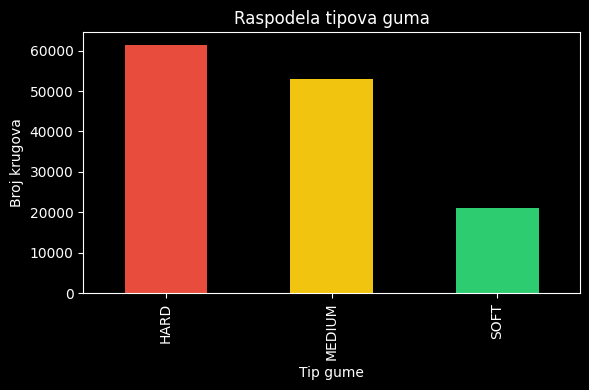

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
compound_counts.sort_index().plot(kind="bar", ax=ax, color=["#e74c3c", "#f1c40f", "#2ecc71"])
ax.set_title("Raspodela tipova guma")
ax.set_xlabel("Tip gume")
ax.set_ylabel("Broj krugova")
plt.tight_layout()

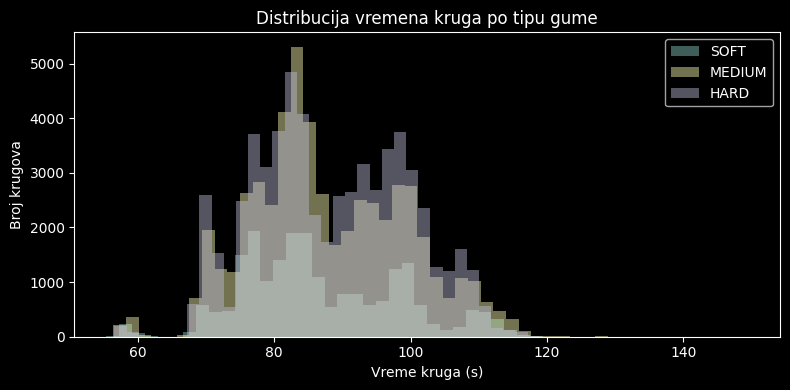

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for compound in ["SOFT", "MEDIUM", "HARD"]:
    subset = processed_laps.loc[processed_laps["Compound"].astype(str) == compound, "LapTime"]
    if not subset.empty:
        ax.hist(subset, bins=50, alpha=0.45, label=compound)

ax.set_title("Distribucija vremena kruga po tipu gume")
ax.set_xlabel("Vreme kruga (s)")
ax.set_ylabel("Broj krugova")
ax.legend()
plt.tight_layout()

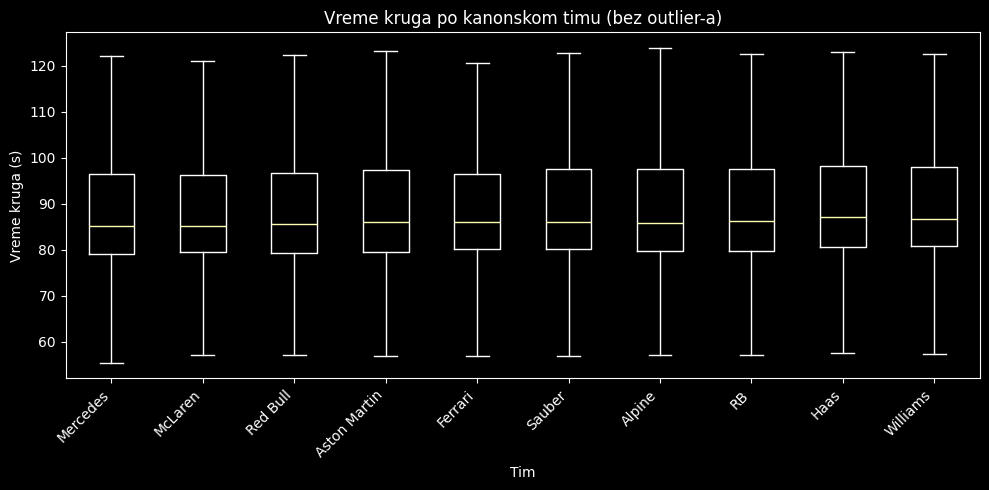

In [7]:
top_teams = processed_laps["CanonicalTeam"].astype(str).value_counts().head(10).index
box_data = [processed_laps.loc[processed_laps["CanonicalTeam"].astype(str) == team, "LapTime"].values for team in top_teams]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(box_data, tick_labels=top_teams, showfliers=False)
ax.set_title("Vreme kruga po kanonskom timu (bez outlier-a)")
ax.set_xlabel("Tim")
ax.set_ylabel("Vreme kruga (s)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

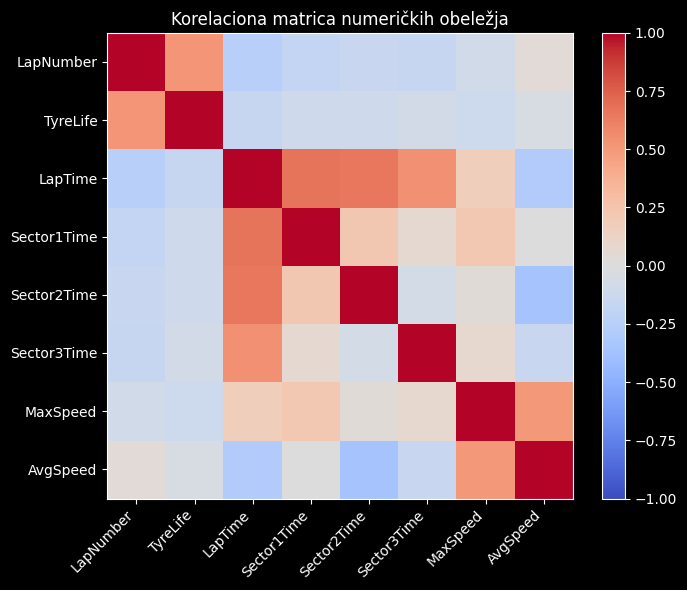

In [8]:
corr_cols = ["LapNumber", "TyreLife", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time", "MaxSpeed", "AvgSpeed"]
corr = processed_laps[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Korelaciona matrica numeričkih obeležja")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

## 5. Klasifikacija tipa gume

U ovom delu modeli predviđaju tip gume (`SOFT`, `MEDIUM`, `HARD`) na osnovu karakteristika kruga.
Evaluacija se radi na validation i test delu, kako bi prikazane metrike odražavale generalizaciju modela.


In [9]:
classification_metrics = evaluate_classification_models(
    processed_laps,
    output_dir=results_path / "classification",
    random_state=42,
)
classification_metrics

,run_id,run_timestamp,model,split,macro_f1,weighted_f1,model_params
0,20260302T204452540153Z,2026-03-02T20:44:52Z,RandomForest,validation,0.775349,0.793145,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
1,20260302T204452540153Z,2026-03-02T20:44:52Z,RandomForest,test,0.775458,0.793687,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
2,20260302T204452540153Z,2026-03-02T20:44:52Z,XGBoost,validation,0.748612,0.765448,"{""base_score"": null, ""booster"": null, ""callbac..."
3,20260302T204452540153Z,2026-03-02T20:44:52Z,XGBoost,test,0.746011,0.764702,"{""base_score"": null, ""booster"": null, ""callbac..."


In [10]:
classification_history_path = results_path / "classification/classification_metrics_history.csv"
latest_classification_meta = results_path / "classification/latest_run.json"
preferred_classification_run_id = None
if latest_classification_meta.exists():
    import json as _json
    preferred_classification_run_id = _json.loads(latest_classification_meta.read_text(encoding="utf-8")).get("run_id")

if classification_history_path.exists():
    try:
        classification_history = pd.read_csv(classification_history_path)
    except Exception:
        classification_history = pd.read_csv(classification_history_path, engine="python", on_bad_lines="skip")

    classification_history["run_timestamp"] = pd.to_datetime(classification_history["run_timestamp"], errors="coerce")
    if preferred_classification_run_id is not None and preferred_classification_run_id in set(classification_history["run_id"]):
        latest_classification_run_id = preferred_classification_run_id
    else:
        latest_classification_run_id = classification_history.sort_values("run_timestamp").iloc[-1]["run_id"]
    classification_metrics_latest = classification_history[classification_history["run_id"] == latest_classification_run_id].copy()
else:
    latest_classification_run_id = classification_metrics["run_id"].iloc[-1] if "run_id" in classification_metrics.columns else None
    classification_metrics_latest = classification_metrics.copy()

print(f"Poslednji run klasifikacije: {latest_classification_run_id}")
classification_metrics_latest



Poslednji run klasifikacije: 20260302T204452540153Z


,run_id,run_timestamp,model,split,macro_f1,weighted_f1,model_params
44,20260302T204452540153Z,2026-03-02 20:44:52+00:00,RandomForest,validation,0.775349,0.793145,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
45,20260302T204452540153Z,2026-03-02 20:44:52+00:00,RandomForest,test,0.775458,0.793687,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
46,20260302T204452540153Z,2026-03-02 20:44:52+00:00,XGBoost,validation,0.748612,0.765448,"{""base_score"": null, ""booster"": null, ""callbac..."
47,20260302T204452540153Z,2026-03-02 20:44:52+00:00,XGBoost,test,0.746011,0.764702,"{""base_score"": null, ""booster"": null, ""callbac..."


### 5.1 Vizualizacija evaluacije klasifikacije (poslednji run)

Grafici prikazuju poređenje modela po metrikama (`macro_f1`, `weighted_f1`), dok confusion matrix pokazuje koje klase model najčešće meša.
Na ovaj način se vidi ne samo ukupni rezultat, već i struktura grešaka.


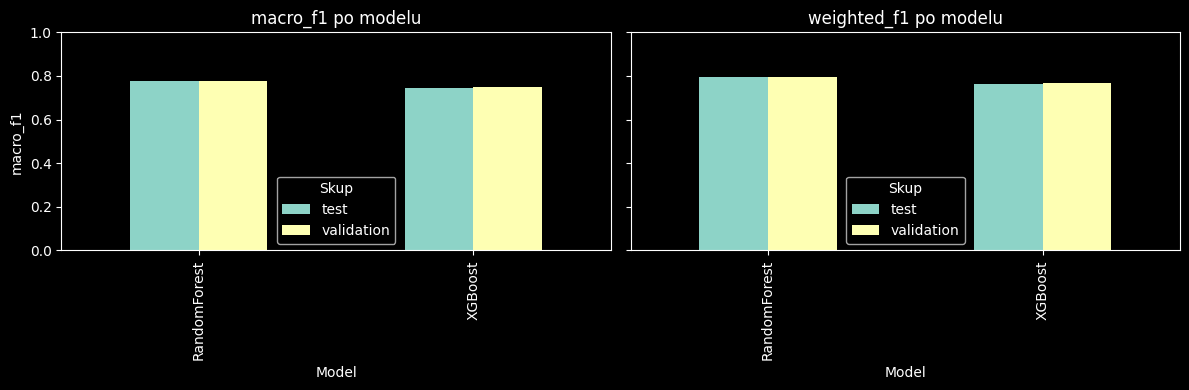

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for idx, metric_col in enumerate(["macro_f1", "weighted_f1"]):
    pivot = classification_metrics_latest.pivot(index="model", columns="split", values=metric_col)
    pivot.plot(kind="bar", ax=axes[idx])
    axes[idx].set_title(f"{metric_col} po modelu")
    axes[idx].set_xlabel("Model")
    axes[idx].set_ylabel(metric_col)
    axes[idx].set_ylim(0, 1)
    axes[idx].legend(title="Skup")
plt.tight_layout()

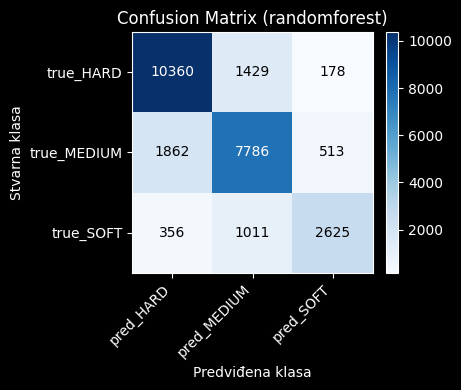

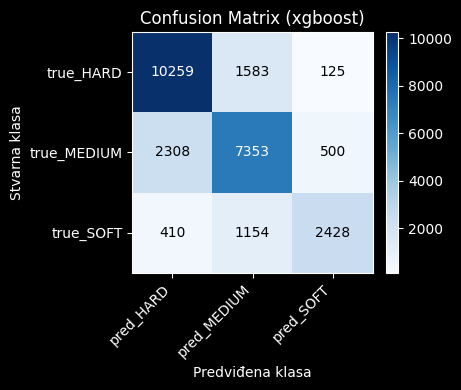

In [12]:
if latest_classification_run_id is not None:
    cm_files = sorted((results_path / "classification/runs").glob(f"confusion_matrix_test_*__{latest_classification_run_id}.csv"))
else:
    cm_files = sorted((results_path / "classification").glob("confusion_matrix_test_*.csv"))

if not cm_files:
    print("Nema confusion matrix fajlova za poslednji run.")

for cm_file in cm_files:
    cm_df = pd.read_csv(cm_file, index_col=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_df.values, cmap="Blues")
    ax.set_xticks(np.arange(cm_df.shape[1]))
    ax.set_yticks(np.arange(cm_df.shape[0]))
    ax.set_xticklabels(cm_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm_df.index)

    threshold = cm_df.values.max() * 0.5 if cm_df.values.size else 0
    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            value = int(cm_df.iat[i, j])
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=10)

    model_label = cm_file.stem.replace("confusion_matrix_test_", "")
    model_label = model_label.split("__")[0]
    ax.set_title(f"Confusion Matrix ({model_label})")
    ax.set_xlabel("Predviđena klasa")
    ax.set_ylabel("Stvarna klasa")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

## 6. Klasterovanje krugova

Klasterovanje grupiše krugove po sličnosti performansi i uslova vožnje, bez direktnog korišćenja ciljnih klasa tokom treniranja.
Rezultati se zatim porede sa kanonskim timskim etiketama radi procene smislenosti dobijenih grupa.


In [13]:
clustering_metrics = evaluate_clustering_models(
    processed_laps,
    output_dir=results_path / "clustering",
    random_state=42,
)
clustering_metrics

,run_id,run_timestamp,model,split,label_basis,feature_space,clustering_strategy,n_clusters,adjusted_rand_index,cluster_purity,model_params
0,20260302T204502674809Z,2026-03-02T20:45:02Z,KMeans,validation,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.231965,0.395902,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":..."
1,20260302T204502674809Z,2026-03-02T20:45:02Z,KMeans,test,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.230447,0.394719,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":..."
2,20260302T204502674809Z,2026-03-02T20:45:02Z,GMM,validation,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.294336,0.482567,"{""covariance_type"": ""full"", ""init_params"": ""km..."
3,20260302T204502674809Z,2026-03-02T20:45:02Z,GMM,test,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.290458,0.477612,"{""covariance_type"": ""full"", ""init_params"": ""km..."


In [14]:
clustering_history_path = results_path / "clustering/clustering_metrics_history.csv"
latest_clustering_meta = results_path / "clustering/latest_run.json"
preferred_clustering_run_id = None
if latest_clustering_meta.exists():
    import json as _json
    preferred_clustering_run_id = _json.loads(latest_clustering_meta.read_text(encoding="utf-8")).get("run_id")

if clustering_history_path.exists():
    try:
        clustering_history = pd.read_csv(clustering_history_path)
    except Exception:
        clustering_history = pd.read_csv(clustering_history_path, engine="python", on_bad_lines="skip")

    clustering_history["run_timestamp"] = pd.to_datetime(clustering_history["run_timestamp"], errors="coerce")
    if preferred_clustering_run_id is not None and preferred_clustering_run_id in set(clustering_history["run_id"]):
        latest_clustering_run_id = preferred_clustering_run_id
    else:
        latest_clustering_run_id = clustering_history.sort_values("run_timestamp").iloc[-1]["run_id"]
    clustering_metrics_latest = clustering_history[clustering_history["run_id"] == latest_clustering_run_id].copy()
else:
    latest_clustering_run_id = clustering_metrics["run_id"].iloc[-1] if "run_id" in clustering_metrics.columns else None
    clustering_metrics_latest = clustering_metrics.copy()

print(f"Poslednji run klasterovanja: {latest_clustering_run_id}")
clustering_metrics_latest



Poslednji run klasterovanja: 20260302T204502674809Z


,run_id,run_timestamp,model,label_basis,feature_space,clustering_strategy,n_clusters,adjusted_rand_index,cluster_purity,model_params,split
34,20260302T204502674809Z,2026-03-02 20:45:02+00:00,KMeans,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.231965,0.395902,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":...",validation
35,20260302T204502674809Z,2026-03-02 20:45:02+00:00,KMeans,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.230447,0.394719,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":...",test
36,20260302T204502674809Z,2026-03-02 20:45:02+00:00,GMM,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.294336,0.482567,"{""covariance_type"": ""full"", ""init_params"": ""km...",validation
37,20260302T204502674809Z,2026-03-02 20:45:02+00:00,GMM,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.290458,0.477612,"{""covariance_type"": ""full"", ""init_params"": ""km...",test


### 6.1 Vizualizacija evaluacije klasterovanja (poslednji run)

Prikazane su metrike klasterovanja (`adjusted_rand_index`, `cluster_purity`) i raspodele timova po klasterima.
Vizualizacije služe da procene koliko klasteri prate realne obrasce u podacima.


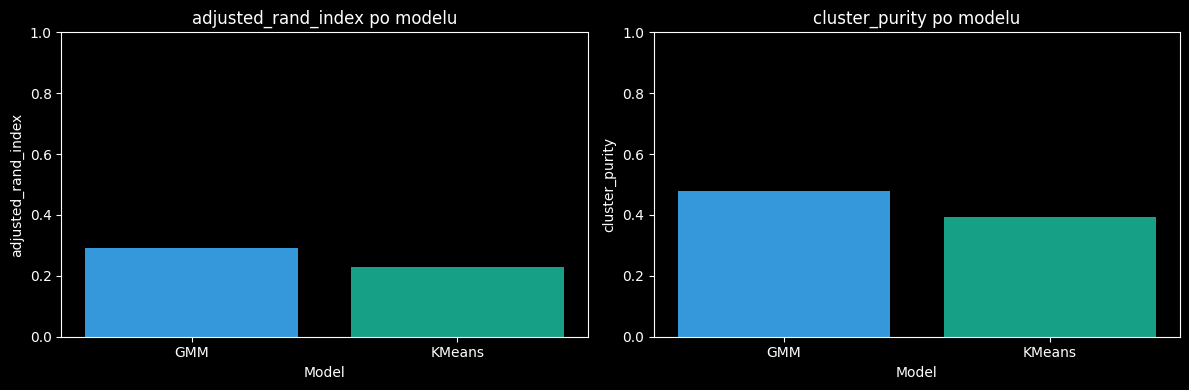

In [15]:
plot_cols = ["adjusted_rand_index", "cluster_purity"]
plot_df = clustering_metrics_latest.copy()
if "split" in plot_df.columns:
    test_df = plot_df[plot_df["split"].astype(str) == "test"].copy()
    if not test_df.empty:
        plot_df = test_df

plot_df = plot_df.groupby("model", as_index=False)[plot_cols].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, metric_col in enumerate(plot_cols):
    axes[idx].bar(plot_df["model"], plot_df[metric_col], color=["#3498db", "#16a085"])
    axes[idx].set_title(f"{metric_col} po modelu")
    axes[idx].set_xlabel("Model")
    axes[idx].set_ylabel(metric_col)
    axes[idx].set_ylim(0, 1)

plt.tight_layout()



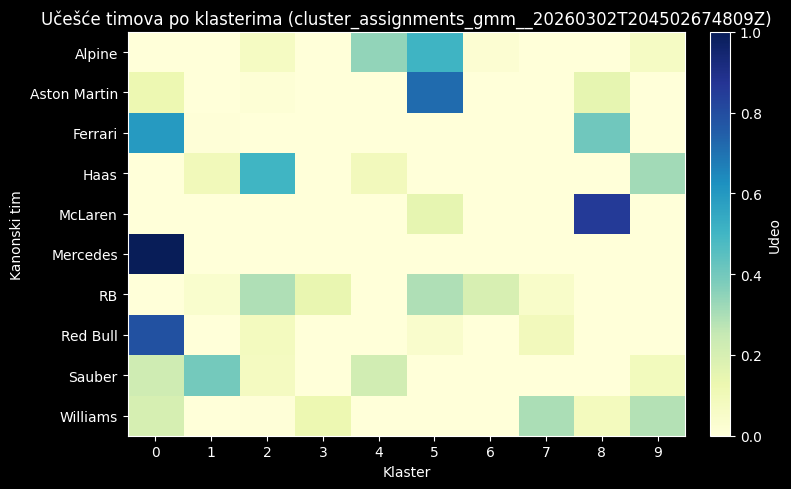

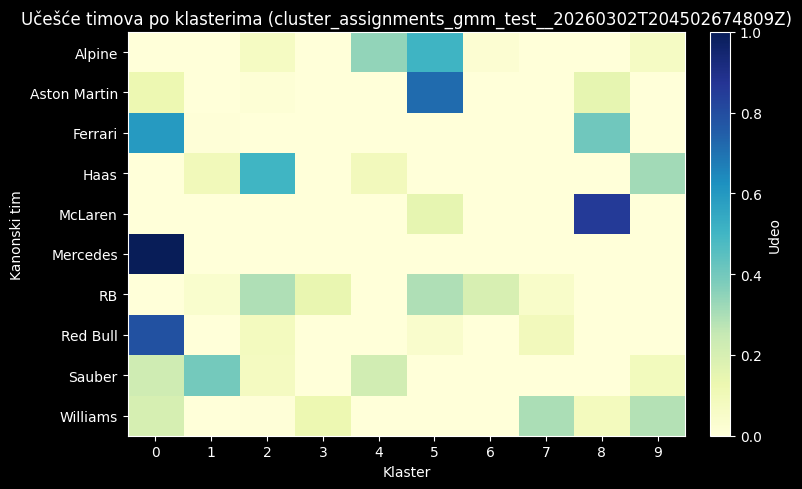

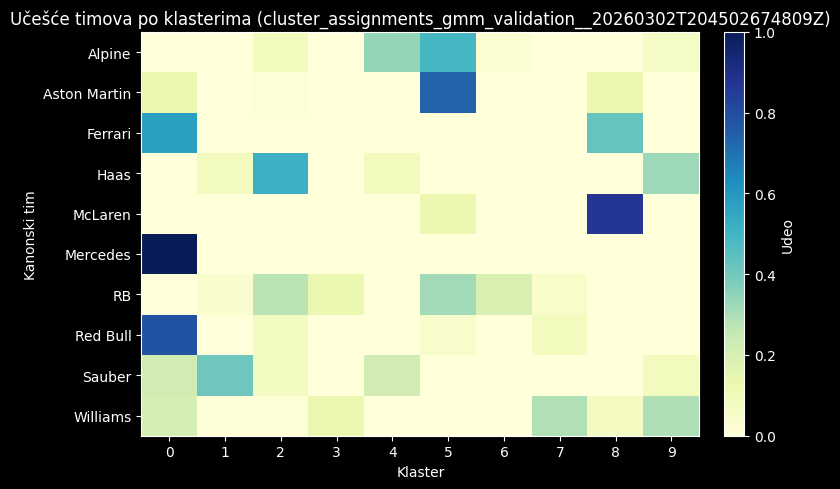

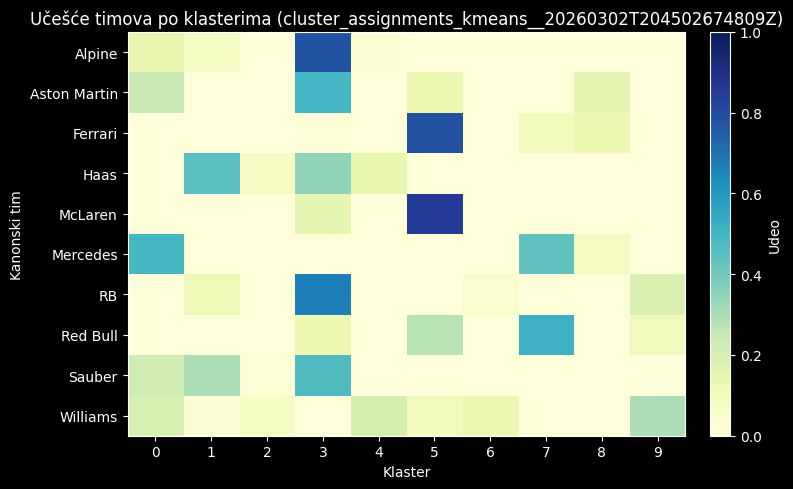

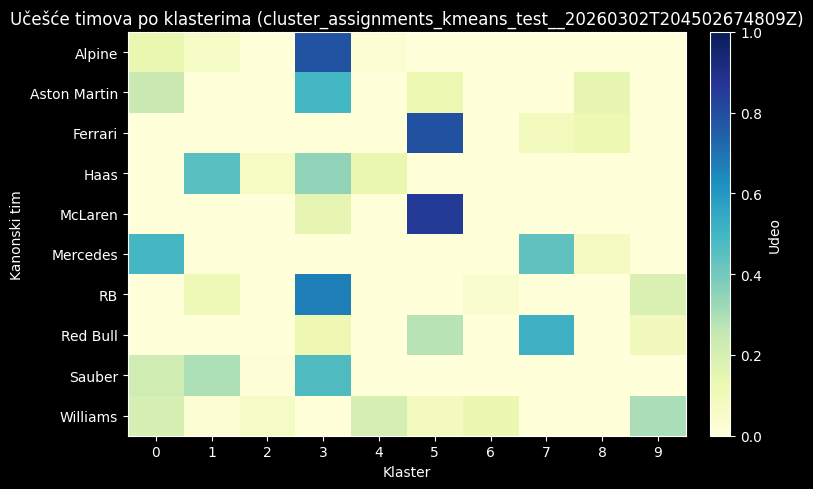

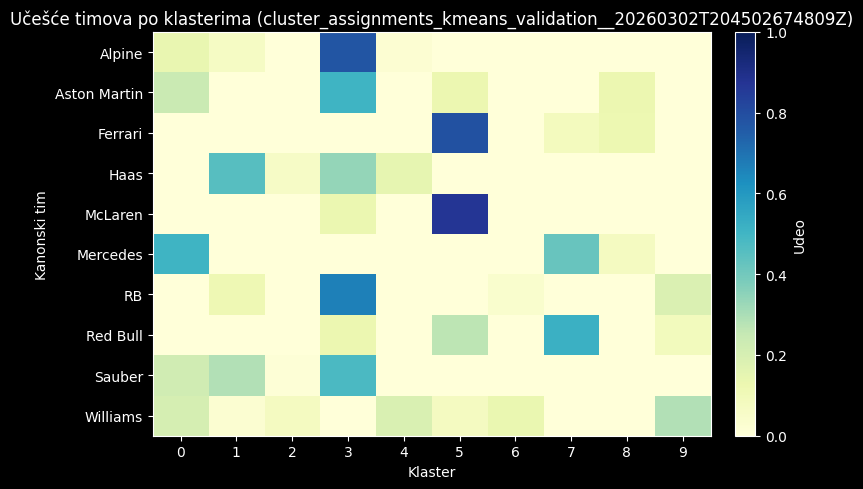

In [16]:
if latest_clustering_run_id is not None:
    assignment_files = sorted((results_path / "clustering/runs").glob(f"cluster_assignments_*_test__{latest_clustering_run_id}.csv"))
    # Fallback za starije run-ove koji imaju samo legacy naziv fajla
    if not assignment_files:
        assignment_files = sorted((results_path / "clustering/runs").glob(f"cluster_assignments_*__{latest_clustering_run_id}.csv"))
else:
    assignment_files = sorted((results_path / "clustering").glob("cluster_assignments_*_test.csv"))
    if not assignment_files:
        assignment_files = sorted((results_path / "clustering").glob("cluster_assignments_*.csv"))

for assignment_file in assignment_files:
    assign_df = pd.read_csv(assignment_file)
    if "CanonicalTeam" not in assign_df.columns:
        continue

    contingency = pd.crosstab(assign_df["CanonicalTeam"], assign_df["cluster"], normalize="index")

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(contingency.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(np.arange(contingency.shape[1]))
    ax.set_yticks(np.arange(contingency.shape[0]))
    ax.set_xticklabels(contingency.columns)
    ax.set_yticklabels(contingency.index)
    ax.set_xlabel("Klaster")
    ax.set_ylabel("Kanonski tim")
    ax.set_title(f"Učešće timova po klasterima ({assignment_file.stem})")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Udeo")
    plt.tight_layout()
    plt.show()



### 6.2 Provera train-fitted preprocessing-a (split summary)

U ovoj sekciji prikazujemo detalje preprocessing-a po splitovima: veličine skupova i broj uklonjenih outlier-a.
Cilj je da bude transparentno kako je obrada podataka primenjena pre evaluacije modela.


In [17]:
import json

cls_split_summary_path = results_path / "classification/split_summary.json"
clu_split_summary_path = results_path / "clustering/split_summary.json"

if cls_split_summary_path.exists():
    with cls_split_summary_path.open("r", encoding="utf-8") as f:
        cls_split_summary = json.load(f)
    print("Klasifikacija split summary:")
    print(json.dumps(cls_split_summary.get("preprocessing", {}), ensure_ascii=False, indent=2))

if clu_split_summary_path.exists():
    with clu_split_summary_path.open("r", encoding="utf-8") as f:
        clu_split_summary = json.load(f)
    print("Klasterovanje split summary:")
    print(json.dumps(clu_split_summary.get("preprocessing", {}), ensure_ascii=False, indent=2))


Klasifikacija split summary:
{
  "fit_on": "train_only",
  "iqr_outlier_filter": {
    "value_column": "LapTime",
    "group_columns": [
      "Year",
      "EventName",
      "Driver"
    ],
    "iqr_multiplier": 1.5,
    "rows_removed": {
      "train": 2249,
      "validation": 1016,
      "test": 1015
    }
  },
  "numeric_scaler": null,
  "applied_to": [
    "train",
    "validation",
    "test"
  ]
}
Klasterovanje split summary:
{
  "fit_on": "train_only",
  "iqr_outlier_filter": {
    "value_column": "LapTime",
    "group_columns": [
      "Year",
      "EventName",
      "Driver"
    ],
    "iqr_multiplier": 1.5,
    "rows_removed": {
      "train": 2162,
      "validation": 977,
      "test": 1005
    }
  },
  "event_compound_zscore": true,
  "numeric_scaler": "StandardScaler",
  "driver_one_hot": true,
  "applied_to": [
    "train",
    "validation",
    "test"
  ]
}


## 7. Istorija svih run-ova i parametri modela

Na kraju prikazujemo istoriju eksperimenata: vreme pokretanja, parametre modela i ostvarene metrike.
Ovaj pregled omogućava poređenje više run-ova i jasno dokumentuje kako su rezultati dobijeni.


In [18]:
saved_classification_history = pd.read_csv(results_path / "classification/classification_metrics_history.csv")
saved_clustering_history = pd.read_csv(results_path / "clustering/clustering_metrics_history.csv")

saved_classification_history = saved_classification_history.sort_values("run_timestamp")
saved_clustering_history = saved_clustering_history.sort_values("run_timestamp")

print("Klasifikacija - poslednjih 10 zapisa:")
display(saved_classification_history.tail(10))

print("Klasterovanje - poslednjih 10 zapisa:")
display(saved_clustering_history.tail(10))

Klasifikacija - poslednjih 10 zapisa:


,run_id,run_timestamp,model,split,macro_f1,weighted_f1,model_params
38,20260302T203542485212Z,2026-03-02T20:35:42Z,XGBoost,validation,0.748612,0.765448,"{""base_score"": null, ""booster"": null, ""callbac..."
39,20260302T203542485212Z,2026-03-02T20:35:42Z,XGBoost,test,0.746011,0.764702,"{""base_score"": null, ""booster"": null, ""callbac..."
40,20260302T203816914050Z,2026-03-02T20:38:16Z,RandomForest,validation,0.775349,0.793145,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
41,20260302T203816914050Z,2026-03-02T20:38:16Z,RandomForest,test,0.775458,0.793687,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
42,20260302T203816914050Z,2026-03-02T20:38:16Z,XGBoost,validation,0.748612,0.765448,"{""base_score"": null, ""booster"": null, ""callbac..."
43,20260302T203816914050Z,2026-03-02T20:38:16Z,XGBoost,test,0.746011,0.764702,"{""base_score"": null, ""booster"": null, ""callbac..."
46,20260302T204452540153Z,2026-03-02T20:44:52Z,XGBoost,validation,0.748612,0.765448,"{""base_score"": null, ""booster"": null, ""callbac..."
44,20260302T204452540153Z,2026-03-02T20:44:52Z,RandomForest,validation,0.775349,0.793145,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
45,20260302T204452540153Z,2026-03-02T20:44:52Z,RandomForest,test,0.775458,0.793687,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""class_w..."
47,20260302T204452540153Z,2026-03-02T20:44:52Z,XGBoost,test,0.746011,0.764702,"{""base_score"": null, ""booster"": null, ""callbac..."


Klasterovanje - poslednjih 10 zapisa:


,run_id,run_timestamp,model,label_basis,feature_space,clustering_strategy,n_clusters,adjusted_rand_index,cluster_purity,model_params,split
27,20260302T203627931447Z,2026-03-02T20:36:27Z,KMeans,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_lap_predict,10,0.048499,0.023574,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":...",test
28,20260302T203627931447Z,2026-03-02T20:36:27Z,GMM,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit,10,0.216668,0.024467,"{""covariance_type"": ""diag"", ""init_params"": ""km...",validation
30,20260302T203816914050Z,2026-03-02T20:38:16Z,KMeans,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.231965,0.395902,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":...",validation
31,20260302T203816914050Z,2026-03-02T20:38:16Z,KMeans,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.230447,0.394719,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":...",test
32,20260302T203816914050Z,2026-03-02T20:38:16Z,GMM,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.294336,0.482567,"{""covariance_type"": ""full"", ""init_params"": ""km...",validation
33,20260302T203816914050Z,2026-03-02T20:38:16Z,GMM,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.290458,0.477612,"{""covariance_type"": ""full"", ""init_params"": ""km...",test
35,20260302T204502674809Z,2026-03-02T20:45:02Z,KMeans,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.230447,0.394719,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":...",test
36,20260302T204502674809Z,2026-03-02T20:45:02Z,GMM,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.294336,0.482567,"{""covariance_type"": ""full"", ""init_params"": ""km...",validation
34,20260302T204502674809Z,2026-03-02T20:45:02Z,KMeans,CanonicalTeam,event_compound_zscore_numeric_plus_driver,driver_profile_trainfit_driver_profile_predict,10,0.231965,0.395902,"{""algorithm"": ""lloyd"", ""copy_x"": true, ""init"":...",validation
37,20260302T204502674809Z,2026-03-02T20:45:02Z,GMM,CanonicalTeam,event_compound_zscore_numeric_plus_driver,direct_lap_clustering_trainfit_cov_full,10,0.290458,0.477612,"{""covariance_type"": ""full"", ""init_params"": ""km...",test
